# Estudio del Problema del Bandido de k-Brazos

**Asignatura**: Extensiones de Machine Learning — Máster en Inteligencia Artificial (UMU)

---

Este notebook recoge el trabajo realizado en la Parte 1 de la práctica de Aprendizaje por Refuerzo:



## Preparación del entorno

In [1]:
import sys
import os

# Añadir el directorio raíz del proyecto al path
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
from typing import List

# Importar clases de brazos
from arms import Arm, ArmNormal, ArmBernoulli, ArmBinomial, Bandit

# Importar algoritmos
from algorithms import Algorithm, EpsilonGreedy

# Importar funciones de plotting
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics

# Importar run_experiment desde main
from main import run_experiment

# Matplotlib inline para notebooks
import matplotlib.pyplot as plt
%matplotlib inline

print("Entorno cargado correctamente.")

Entorno cargado correctamente.


---
# PARTE 1: Tipos de Brazos (Distribuciones de Recompensa)

En el problema del bandido de k-brazos, cada brazo devuelve una recompensa según una distribución de probabilidad **desconocida** para el agente. Hemos implementado tres tipos de distribuciones:

| Distribución | Recompensa | E[X] | Var[X] | Ejemplo real |
|---|---|---|---|---|
| **Bernoulli(p)** | {0, 1} | p | p(1-p) | Publicidad online (clic vs. no clic) |
| **Binomial(n, p)** | {0, ..., n} | n·p | np(1-p) | Promociones app delivery (cuántos de n usuarios convierten) |
| **Normal(μ, σ²)** | ℝ | μ | σ² | Tiempo de visualización en streaming |

**Relación teórica clave**:
- Bernoulli(p) ≡ Binomial(1, p) → caso particular
- Si np ≥ 5 y n(1-p) ≥ 5: Binomial(n,p) ≈ Normal(np, np(1-p)) → aproximación normal

## 1.1 Brazo Normal 

El brazo normal ya estaba implementado en el repositorio original. Cada brazo sigue una distribución $X \sim N(\mu, \sigma^2)$ con $\sigma = 1$ fijo.

Generamos 10 brazos normales para visualizar sus parámetros:

In [2]:
np.random.seed(42)

k = 10
brazos_normal = ArmNormal.generate_arms(k)
bandit_normal = Bandit(arms=brazos_normal)

print(f"Bandido Normal con {k} brazos:")
print("=" * 60)
for i, arm in enumerate(brazos_normal):
    marker = " ★ ÓPTIMO" if i == bandit_normal.optimal_arm else ""
    print(f"  Brazo {i+1}: {arm} → E[X] = {arm.get_expected_value():.2f}{marker}")
print(f"\nBrazo óptimo: {bandit_normal.optimal_arm + 1} con E[X] = {bandit_normal.get_expected_value(bandit_normal.optimal_arm):.2f}")

Bandido Normal con 10 brazos:
  Brazo 1: ArmNormal(mu=4.37, sigma=1.0) → E[X] = 4.37
  Brazo 2: ArmNormal(mu=9.56, sigma=1.0) → E[X] = 9.56 ★ ÓPTIMO
  Brazo 3: ArmNormal(mu=7.59, sigma=1.0) → E[X] = 7.59
  Brazo 4: ArmNormal(mu=6.39, sigma=1.0) → E[X] = 6.39
  Brazo 5: ArmNormal(mu=2.4, sigma=1.0) → E[X] = 2.40
  Brazo 6: ArmNormal(mu=1.52, sigma=1.0) → E[X] = 1.52
  Brazo 7: ArmNormal(mu=8.8, sigma=1.0) → E[X] = 8.80
  Brazo 8: ArmNormal(mu=6.41, sigma=1.0) → E[X] = 6.41
  Brazo 9: ArmNormal(mu=7.37, sigma=1.0) → E[X] = 7.37
  Brazo 10: ArmNormal(mu=1.19, sigma=1.0) → E[X] = 1.19

Brazo óptimo: 2 con E[X] = 9.56


Visualicemos las distribuciones de algunos brazos para entender la variabilidad:

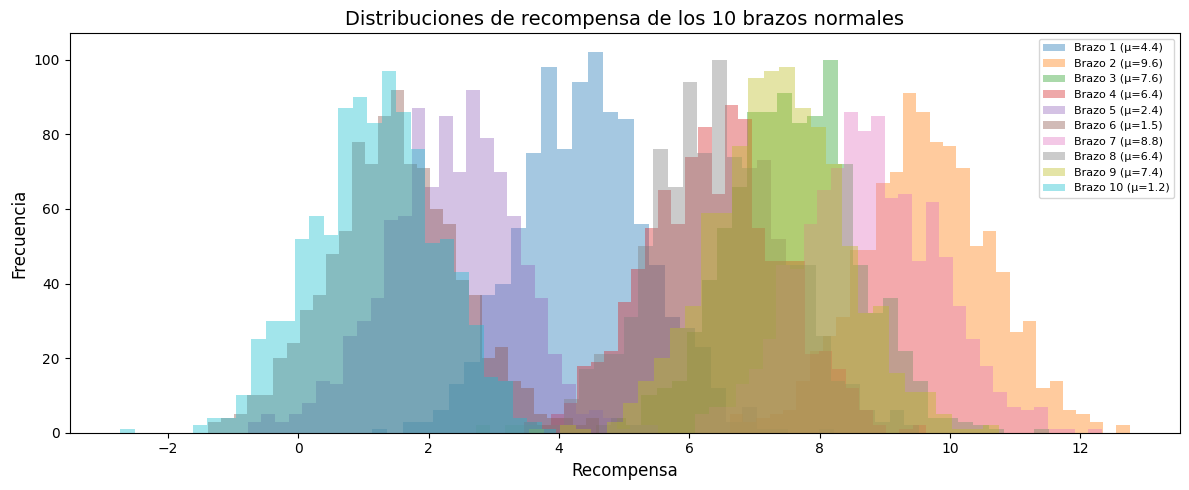

In [3]:
np.random.seed(42)
fig, ax = plt.subplots(figsize=(12, 5))

# Muestrear 1000 recompensas de cada brazo para visualizar distribuciones
for i, arm in enumerate(brazos_normal):
    samples = [arm.pull() for _ in range(1000)]
    ax.hist(samples, bins=30, alpha=0.4, label=f"Brazo {i+1} (μ={arm.mu:.1f})")

ax.set_xlabel("Recompensa", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
ax.set_title("Distribuciones de recompensa de los 10 brazos normales", fontsize=14)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

**Observación**: Con σ=1, las distribuciones se solapan considerablemente. Esto es lo que hace interesante el problema: el agente debe discriminar entre recompensas ruidosas para encontrar el brazo con mayor media.

## 1.2 Brazo Bernoulli 

Modela situaciones binarias de **éxito (1) o fracaso (0)**. Cada brazo tiene una probabilidad $p$ desconocida.

$$X \sim \text{Bernoulli}(p) \quad \Rightarrow \quad E[X] = p, \quad \text{Var}[X] = p(1-p)$$

**Implementación clave**: se usa `np.random.binomial(1, p)` porque Bernoulli(p) ≡ B(1, p).

**Caso de uso**: Publicidad online — al mostrar un anuncio, ¿el usuario hace clic (1) o no (0)?

In [4]:
np.random.seed(42)

k_bern = 10
brazos_bernoulli = ArmBernoulli.generate_arms(k_bern)
bandit_bernoulli = Bandit(arms=brazos_bernoulli)

print(f"Bandido Bernoulli con {k_bern} brazos:")
print("=" * 60)
for i, arm in enumerate(brazos_bernoulli):
    marker = " ★ ÓPTIMO" if i == bandit_bernoulli.optimal_arm else ""
    var = arm.p * (1 - arm.p)
    print(f"  Brazo {i+1}: {arm} → E[X] = {arm.get_expected_value():.3f}, Var = {var:.3f}{marker}")
print(f"\nBrazo óptimo: {bandit_bernoulli.optimal_arm + 1} con p = {bandit_bernoulli.get_expected_value(bandit_bernoulli.optimal_arm):.3f}")

Bandido Bernoulli con 10 brazos:
  Brazo 1: ArmBernoulli(p=0.400) → E[X] = 0.400, Var = 0.240
  Brazo 2: ArmBernoulli(p=0.861) → E[X] = 0.861, Var = 0.120 ★ ÓPTIMO
  Brazo 3: ArmBernoulli(p=0.686) → E[X] = 0.686, Var = 0.215
  Brazo 4: ArmBernoulli(p=0.579) → E[X] = 0.579, Var = 0.244
  Brazo 5: ArmBernoulli(p=0.225) → E[X] = 0.225, Var = 0.174
  Brazo 6: ArmBernoulli(p=0.146) → E[X] = 0.146, Var = 0.125
  Brazo 7: ArmBernoulli(p=0.793) → E[X] = 0.793, Var = 0.164
  Brazo 8: ArmBernoulli(p=0.581) → E[X] = 0.581, Var = 0.243
  Brazo 9: ArmBernoulli(p=0.666) → E[X] = 0.666, Var = 0.222
  Brazo 10: ArmBernoulli(p=0.116) → E[X] = 0.116, Var = 0.103

Brazo óptimo: 2 con p = 0.861


In [5]:
# Demostración: recompensas de un brazo Bernoulli
np.random.seed(42)
brazo_demo = brazos_bernoulli[bandit_bernoulli.optimal_arm]
muestras = [brazo_demo.pull() for _ in range(20)]
print(f"Brazo óptimo (p={brazo_demo.p:.3f}) — 20 muestras:")
print(muestras)
print(f"Proporción de éxitos: {sum(muestras)/len(muestras):.2f} (teórico: {brazo_demo.p:.3f})")

Brazo óptimo (p=0.861) — 20 muestras:
[1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1]
Proporción de éxitos: 0.85 (teórico: 0.861)


**Observación**: La recompensa es siempre 0 o 1. Esto produce una señal muy débil: cada muestra da muy poca información sobre la calidad real del brazo, lo que dificulta y ralentiza el aprendizaje del agente.

## 1.3 Brazo Binomial 

Modela el número de éxitos en n ensayos independientes, cada uno con probabilidad $p$.

$$X \sim B(n, p) \quad \Rightarrow \quad E[X] = n \cdot p, \quad \text{Var}[X] = n \cdot p \cdot (1-p)$$

**Caso de uso**: Promociones en app de delivery — se muestra una promoción a n=100 usuarios y se cuenta cuántos la aprovechan.

In [6]:
np.random.seed(42)

k_bin = 10
n_ensayos = 100  # Lote de 100 usuarios
brazos_binomial = ArmBinomial.generate_arms(k_bin, n=n_ensayos)
bandit_binomial = Bandit(arms=brazos_binomial)

print(f"Bandido Binomial con {k_bin} brazos (n={n_ensayos} ensayos):")
print("=" * 70)
for i, arm in enumerate(brazos_binomial):
    marker = " ★ ÓPTIMO" if i == bandit_binomial.optimal_arm else ""
    var = arm.n * arm.p * (1 - arm.p)
    print(f"  Brazo {i+1}: {arm} → E[X] = {arm.get_expected_value():.1f}, Var = {var:.1f}{marker}")
print(f"\nBrazo óptimo: {bandit_binomial.optimal_arm + 1} con E[X] = {bandit_binomial.get_expected_value(bandit_binomial.optimal_arm):.1f}")

Bandido Binomial con 10 brazos (n=100 ensayos):
  Brazo 1: ArmBinomial(n=100, p=0.400) → E[X] = 40.0, Var = 24.0
  Brazo 2: ArmBinomial(n=100, p=0.861) → E[X] = 86.1, Var = 12.0 ★ ÓPTIMO
  Brazo 3: ArmBinomial(n=100, p=0.686) → E[X] = 68.6, Var = 21.5
  Brazo 4: ArmBinomial(n=100, p=0.579) → E[X] = 57.9, Var = 24.4
  Brazo 5: ArmBinomial(n=100, p=0.225) → E[X] = 22.5, Var = 17.4
  Brazo 6: ArmBinomial(n=100, p=0.146) → E[X] = 14.6, Var = 12.5
  Brazo 7: ArmBinomial(n=100, p=0.793) → E[X] = 79.3, Var = 16.4
  Brazo 8: ArmBinomial(n=100, p=0.581) → E[X] = 58.1, Var = 24.3
  Brazo 9: ArmBinomial(n=100, p=0.666) → E[X] = 66.6, Var = 22.2
  Brazo 10: ArmBinomial(n=100, p=0.116) → E[X] = 11.6, Var = 10.3

Brazo óptimo: 2 con E[X] = 86.1


In [7]:
# Demostración: recompensas de un brazo Binomial
np.random.seed(42)
brazo_demo_bin = brazos_binomial[bandit_binomial.optimal_arm]
muestras_bin = [brazo_demo_bin.pull() for _ in range(20)]
print(f"Brazo óptimo B(n={brazo_demo_bin.n}, p={brazo_demo_bin.p:.3f}) — 20 muestras:")
print(muestras_bin)
print(f"Media observada: {np.mean(muestras_bin):.1f} (teórico: {brazo_demo_bin.get_expected_value():.1f})")

Brazo óptimo B(n=100, p=0.861) — 20 muestras:
[87, 80, 84, 85, 90, 90, 91, 82, 85, 84, 93, 79, 83, 89, 89, 89, 88, 86, 87, 88]
Media observada: 86.5 (teórico: 86.1)


**Observación**: Cada muestra da un valor entre 0 y 100 (número de éxitos de los 100 usuarios). Esto proporciona una señal mucho más rica que Bernoulli: cada observación es más informativa, lo que permite al agente estimar mejor la calidad de cada brazo.

## 1.4 Comparación visual de los tres tipos de brazos

Comparemos visualmente cómo se distribuyen las recompensas de un brazo de cada tipo con parámetros equivalentes:

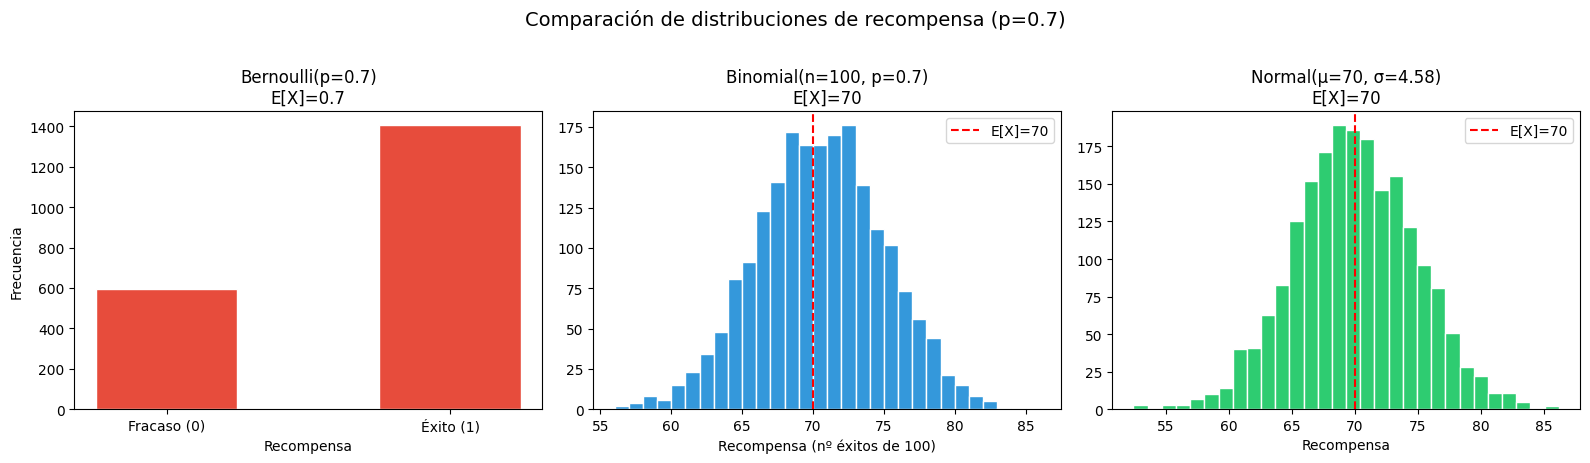

In [8]:
np.random.seed(42)
n_samples = 2000

# Elegimos parámetros comparables: p=0.7 para Bernoulli y Binomial, μ=0.7 para Normal
arm_bern = ArmBernoulli(p=0.7)
arm_binom = ArmBinomial(n=100, p=0.7)
arm_norm = ArmNormal(mu=70, sigma=4.58)  # μ=np=70, σ=sqrt(np(1-p))=sqrt(21)≈4.58

samples_bern = [arm_bern.pull() for _ in range(n_samples)]
samples_binom = [arm_binom.pull() for _ in range(n_samples)]
samples_norm = [arm_norm.pull() for _ in range(n_samples)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Bernoulli
axes[0].hist(samples_bern, bins=[-0.5, 0.5, 1.5], rwidth=0.5, color='#e74c3c', edgecolor='white')
axes[0].set_title(f"Bernoulli(p=0.7)\nE[X]={arm_bern.get_expected_value():.1f}", fontsize=12)
axes[0].set_xlabel("Recompensa")
axes[0].set_ylabel("Frecuencia")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Fracaso (0)', 'Éxito (1)'])

# Binomial
axes[1].hist(samples_binom, bins=30, color='#3498db', edgecolor='white')
axes[1].set_title(f"Binomial(n=100, p=0.7)\nE[X]={arm_binom.get_expected_value():.0f}", fontsize=12)
axes[1].set_xlabel("Recompensa (nº éxitos de 100)")
axes[1].axvline(x=70, color='red', linestyle='--', label='E[X]=70')
axes[1].legend()

# Normal (con los mismos parámetros que la aproximación de la Binomial)
axes[2].hist(samples_norm, bins=30, color='#2ecc71', edgecolor='white')
axes[2].set_title(f"Normal(μ=70, σ=4.58)\nE[X]={arm_norm.get_expected_value():.0f}", fontsize=12)
axes[2].set_xlabel("Recompensa")
axes[2].axvline(x=70, color='red', linestyle='--', label='E[X]=70')
axes[2].legend()

fig.suptitle("Comparación de distribuciones de recompensa (p=0.7)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Análisis comparativo**:

- **Bernoulli**: Solo 0 o 1. La información por muestra es mínima. El agente necesita muchas muestras para estimar $p$ con precisión.
- **Binomial (n=100)**: Recompensas enteras en [0, 100] con forma de campana clara. Cada muestra es mucho más informativa.
- **Normal**: Distribución continua similar a la Binomial (por la aproximación normal), pero permite valores negativos y no está acotada.

La relación teórica se confirma visualmente: la Binomial y la Normal con los mismos parámetros son prácticamente indistinguibles en forma (dado que $np=70 \geq 5$ y $n(1-p)=30 \geq 5$).

### Decisiones de implementación relevantes

| Decisión | Justificación |
|---|---|
| **`list` en lugar de `set` para `generate_arms`** | Los `set` no garantizan orden determinista, comprometiendo la reproducibilidad con semilla fija |
| **Bernoulli usa `binomial(1, p)`** | Refleja la relación teórica Bernoulli(p) ≡ B(1,p) |
| **Parámetros `p_min`, `p_max` configurables** | Permite experimentar con brazos muy similares o muy distintos |
| **Redondeo a 3 decimales** | Legibilidad y unicidad efectiva de parámetros |

---
# PARTE 2: Completar el Estudio de la Familia ε-greedy

El código base del profesor tenía varias partes incompletas. En esta sección mostramos las correcciones realizadas y los resultados obtenidos.

## 2.1 Corrección del caso ε = 0

### El problema

Con la implementación original, cuando ε=0 (greedy puro):
1. Nunca se explora (`random() < 0` es siempre `False`).
2. `argmax(self.values)` siempre devuelve 0 (todos los valores empiezan en 0).
3. El algoritmo se queda atrapado en el brazo 0 sin probar los demás.

### La solución

Se añadió una fase de inicialización: si hay brazos con `counts[i] == 0`, se selecciona uno aleatoriamente antes de aplicar la política greedy.

In [9]:
# Verificación: con ε=0 se prueban todos los brazos
np.random.seed(42)

k_test = 10
bandit_test = Bandit(arms=ArmNormal.generate_arms(k_test))
algo_greedy = EpsilonGreedy(k=k_test, epsilon=0)

selecciones = []
for step in range(k_test):
    arm = algo_greedy.select_arm()
    reward = bandit_test.pull_arm(arm)
    algo_greedy.update(arm, reward)
    selecciones.append(arm)

print(f"Primeras {k_test} selecciones con ε=0: {selecciones}")
print(f"Brazos únicos probados: {len(set(selecciones))} de {k_test}")
print(f"\n✓ Todos los brazos se prueban al menos una vez antes de explotar.")

Primeras 10 selecciones con ε=0: [np.int64(1), np.int64(2), np.int64(9), np.int64(8), np.int64(3), np.int64(5), np.int64(7), np.int64(6), np.int64(0), np.int64(4)]
Brazos únicos probados: 10 de 10

✓ Todos los brazos se prueban al menos una vez antes de explotar.


## 2.2 Configuración del experimento

Configuramos el experimento con los mismos parámetros que propone el enunciado:
- **k = 10 brazos** con distribución Normal
- **1000 pasos** por ejecución
- **500 ejecuciones** independientes (para promediar)
- **3 algoritmos ε-greedy**: ε = 0 (greedy puro), ε = 0.01, ε = 0.1

In [10]:
# Parámetros del experimento
seed = 42
np.random.seed(seed)

k = 10
steps = 1000
runs = 500

# Crear el bandido con brazos normales
bandit = Bandit(arms=ArmNormal.generate_arms(k))
print(bandit)
print(f"\nBrazo óptimo: {bandit.optimal_arm + 1} con E[X] = {bandit.get_expected_value(bandit.optimal_arm):.2f}")

# Definir los 3 algoritmos ε-greedy
algorithms = [
    EpsilonGreedy(k=k, epsilon=0),     # Greedy puro (solo explotación)
    EpsilonGreedy(k=k, epsilon=0.01),  # Exploración mínima (1%)
    EpsilonGreedy(k=k, epsilon=0.1),   # Exploración moderada (10%)
]

print(f"\nEjecutando {runs} ejecuciones de {steps} pasos cada una...")
rewards, optimal_selections, regret_accumulated, arm_stats = run_experiment(bandit, algorithms, steps, runs)
print("¡Experimento completado!")

Bandit with 10 arms: ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0)

Brazo óptimo: 2 con E[X] = 9.56

Ejecutando 500 ejecuciones de 1000 pasos cada una...
¡Experimento completado!


## 2.3 Gráfica 1: Recompensa Promedio vs Pasos de Tiempo

Esta gráfica ya existía en el código del profesor. Muestra la evolución de la recompensa media que obtiene cada algoritmo a lo largo del tiempo.

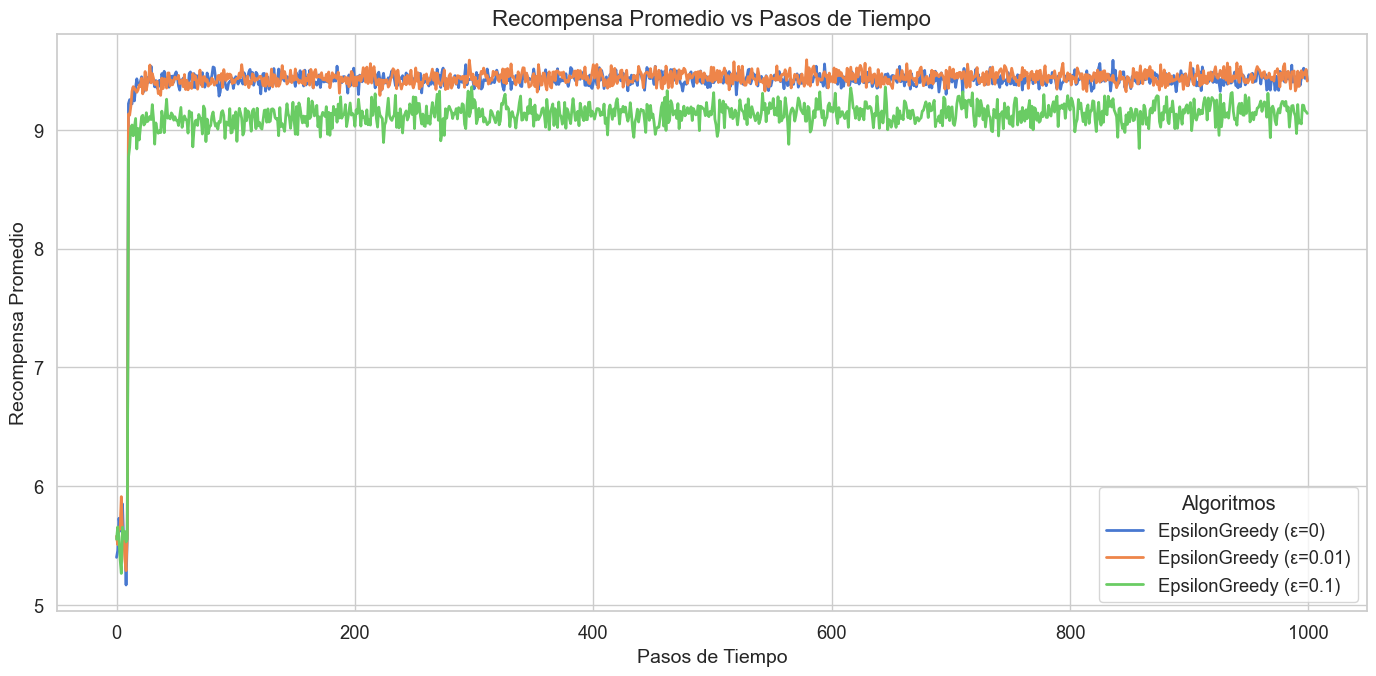

In [11]:
plot_average_rewards(steps, rewards, algorithms)

**Análisis**:

- **ε=0.1 (verde)**: Aprende rápido cuál es el mejor brazo gracias a su 10% de exploración, pero su recompensa se estabiliza por debajo del óptimo teórico porque sigue explorando un 10% del tiempo.
- **ε=0.01 (naranja)**: Converge más lentamente pero, a largo plazo, puede superar a ε=0.1 porque desperdicia menos pasos explorando.
- **ε=0 (azul)**: Con la corrección de inicialización, ahora prueba todos los brazos una vez y luego explota el mejor encontrado. Su rendimiento depende de la "suerte" en esas primeras muestras.

**Limitación de esta gráfica**: No distingue si el agente gana mucho porque elige el brazo correcto o porque tiene suerte con un brazo subóptimo.

## 2.4 Gráfica 2: Selección del Brazo Óptimo 

Muestra el porcentaje de veces que cada algoritmo selecciona **el brazo con mayor valor esperado** a lo largo del tiempo. Esta gráfica responde a la pregunta: *¿está el agente aprendiendo a identificar el mejor brazo?*

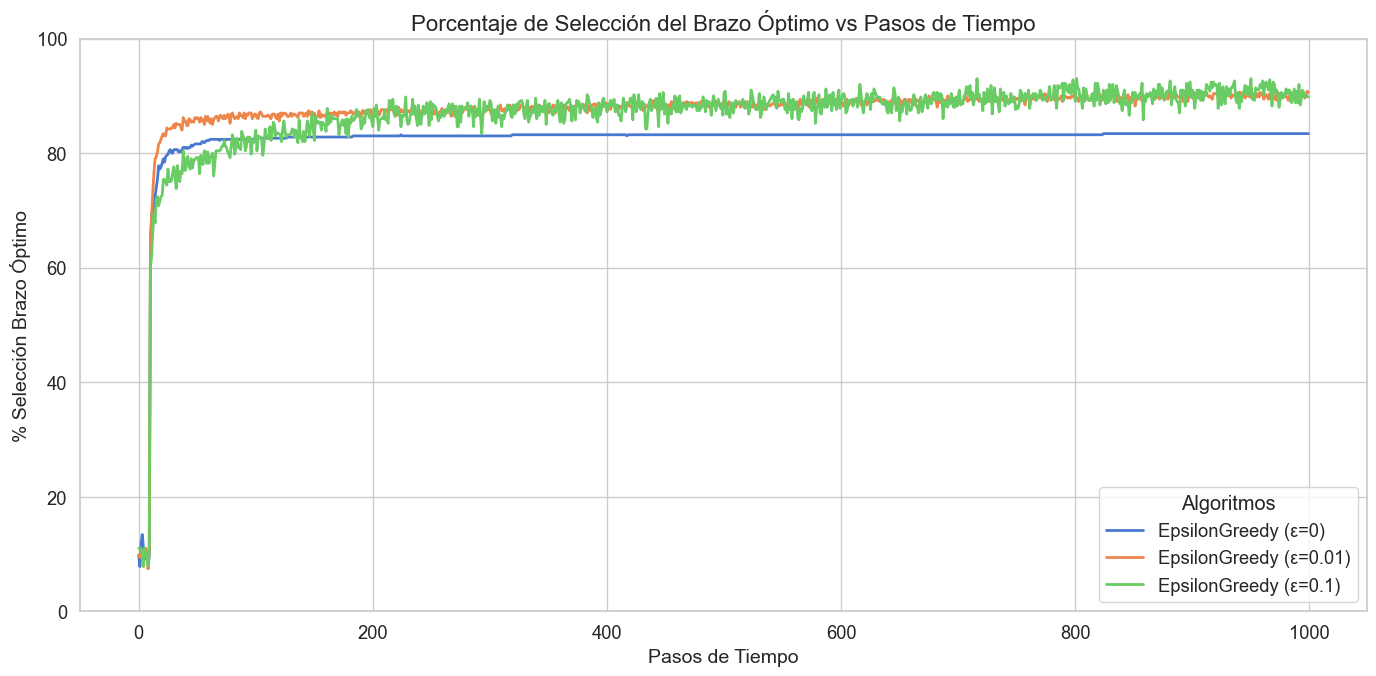

In [12]:
plot_optimal_selections(steps, optimal_selections, algorithms)

**Análisis**:

- **ε=0.1**: Converge rápidamente a seleccionar el brazo óptimo ~91% del tiempo. El 9% restante se debe a la exploración forzada (10% de los pasos elige un brazo al azar, y solo 1/10 de esas veces caerá en el óptimo por casualidad).
- **ε=0.01**: Sube más lentamente pero alcanza ~99% de selección óptima a largo plazo (solo 1% de exploración).
- **ε=0**: Tras la inicialización, se queda fijo en el brazo que cree mejor. Si tuvo suerte, puede llegar a ~100%. Si no, puede quedarse bajo.

Esta gráfica omplementa la recompensa promedio: un algoritmo puede tener alta recompensa sin seleccionar el óptimo (si los brazos son similares), o baja recompensa seleccionando el óptimo (si tiene mala suerte con el ruido). La selección óptima mide directamente el aprendizaje del agente.

## 2.5 Gráfica 3: Regret Acumulado 

El regret acumulado mide la pérdida total por no haber elegido siempre el brazo óptimo:

$$R(T) = \sum_{t=1}^{T} \left( \mu^* - \mu_{a_t} \right)$$

donde $\mu^*$ es el valor esperado del brazo óptimo y $\mu_{a_t}$ es el valor esperado del brazo elegido en el paso $t$.

La línea gris discontinua muestra la cota teórica $C \cdot \ln(T)$ de Lai y Robbins (1985): ningún algoritmo consistente puede tener regret que crezca más lento que logarítmicamente.

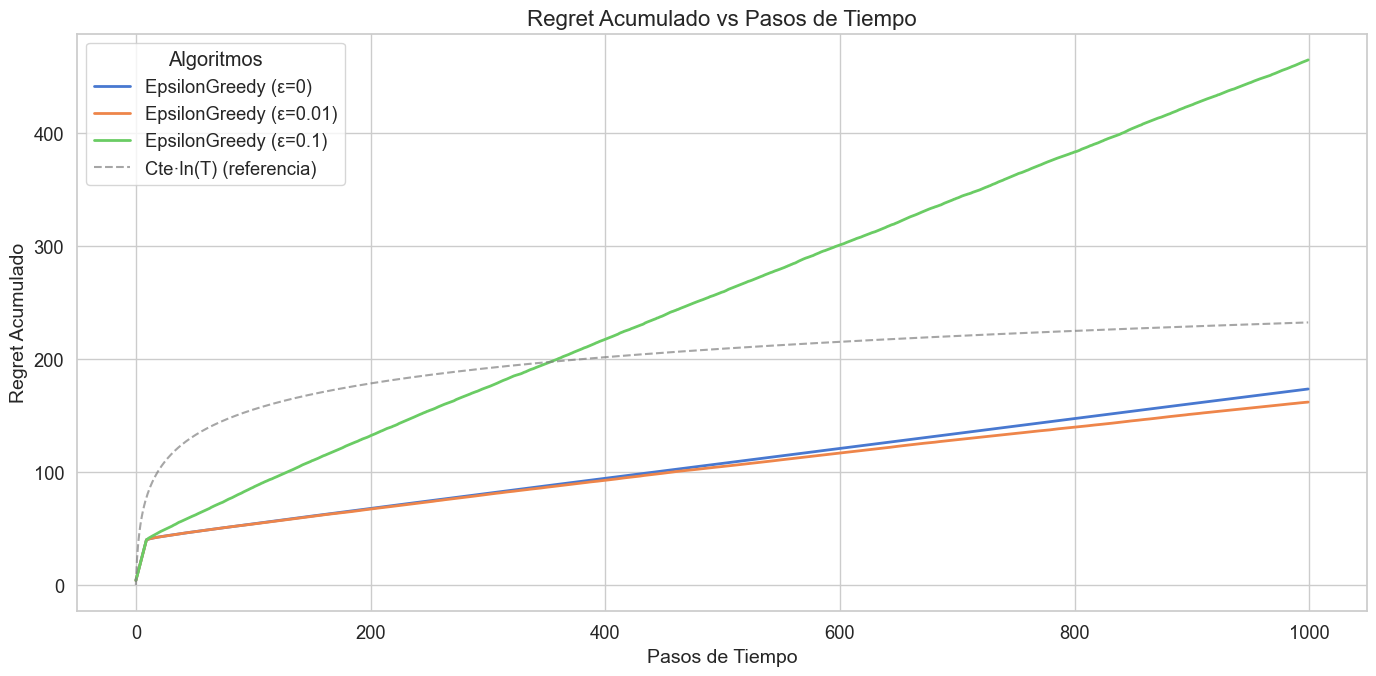

In [13]:
plot_regret(steps, regret_accumulated, algorithms, show_log_bound=True)

**Análisis**:

- **ε=0.1**: El regret crece linealmente. Esto se debe a que el 10% de exploración produce un regret constante por paso. El coste de explorar nunca disminuye.
- **ε=0.01**: Crece también linealmente pero con menor pendiente (solo 1% de exploración forzada).
- **ε=0**: Tras la fase de inicialización, si el algoritmo identifica correctamente el brazo óptimo, el regret se estabiliza (crece muy poco). Si no, crece linealmente.

**Observación importante**: El regret lineal de ε-greedy es una limitación conocida de esta familia de algoritmos. Algoritmos como UCB1 consiguen regret logarítmico $O(\ln T)$, lo que teóricamente los hace superiores a largo plazo. Este será parte del estudio comparativo posterior.

El regret es la medida formal para evaluar la calidad de un algoritmo de bandidos. La recompensa promedio depende de la escala del problema, pero el regret mide directamente cuánto pierde el agente respecto a un oráculo perfecto. Es por ello por lo que le damos dicha importancia.

## 2.6 Gráfica 4: Estadísticas por Brazo 

Muestra, para cada algoritmo, cuántas veces seleccionó cada brazo y qué recompensa media estimó. Permite diagnosticar el comportamiento de exploración/explotación de cada algoritmo.

f:\UM\MASTER\EML\P1\Bandido-k-brazos\eml_k_bandit-main\plotting\plotting.py:202: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
f:\UM\MASTER\ML\ml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


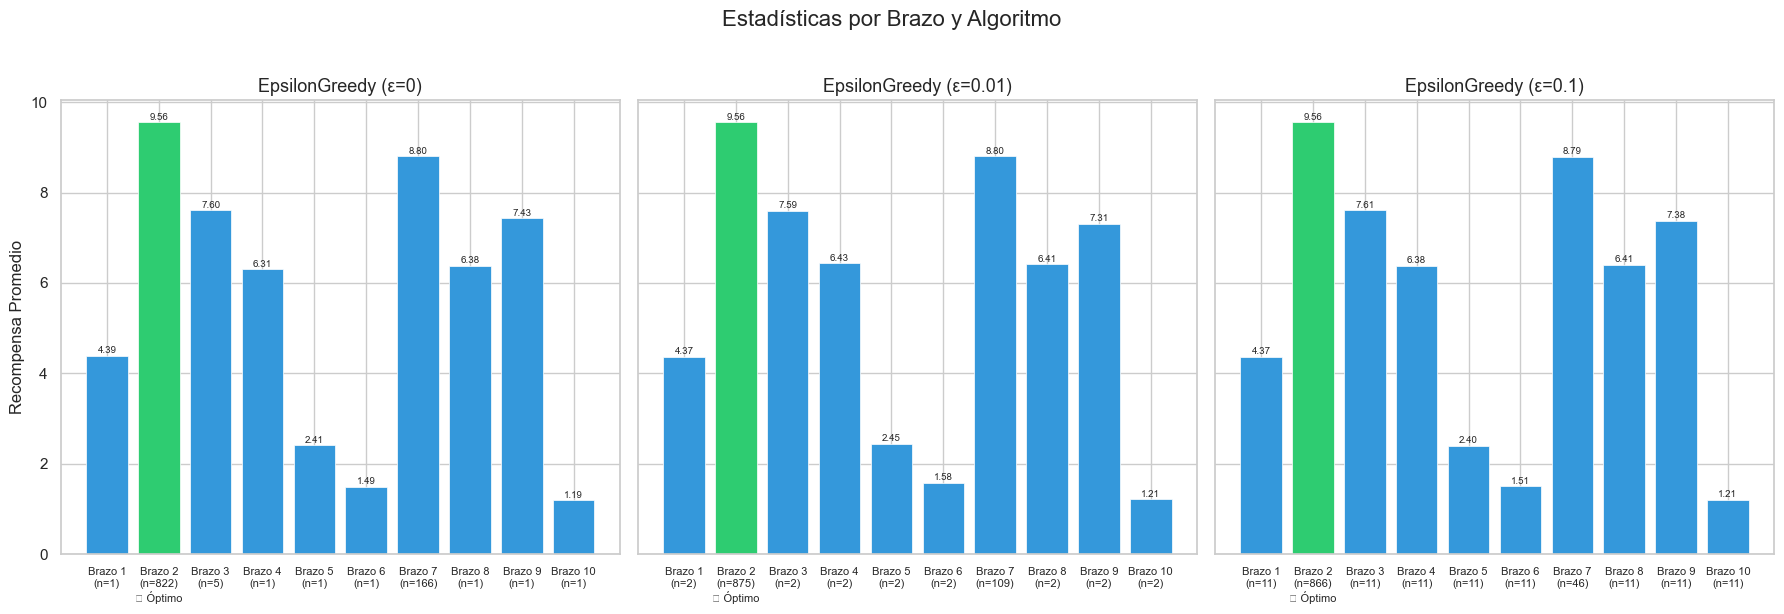

In [14]:
plot_arm_statistics(arm_stats, algorithms)

**Análisis**:

- **ε=0 (Greedy puro)**: Concentra casi todas las selecciones en un solo brazo. Si acertó el óptimo (barra verde alta), funciona bien; si no, pierde mucha recompensa.
- **ε=0.01**: Concentra la mayoría en el brazo óptimo pero distribuye un poco entre los demás (el 1% de exploración).
- **ε=0.1**: Distribuye más selecciones entre todos los brazos. El brazo óptimo sigue siendo el más seleccionado, pero el 10% de exploración es visible.

**Utilidad**: Esta gráfica permite detectar si un algoritmo está "bien calibrado": si concentra demasiado (ε bajo), puede fallar si elige mal al inicio. Si explora demasiado (ε alto), desperdicia selecciones en brazos subóptimos.

## 2.7 ¿Cuáles son las gráficas más relevantes?

De las cuatro gráficas implementadas, las más relevantes para el estudio comparativo son:

1. **Regret acumulado** — Es la métrica estándar en la literatura de bandidos (Sutton & Barto, 2018; Auer et al., 2002). Permite comparar algoritmos independientemente de la escala de recompensas y tiene una cota teórica bien conocida.

2. **Selección del brazo óptimo** — Mide directamente si el agente está aprendiendo a identificar el mejor brazo, algo que la recompensa promedio no captura por sí sola.

La gráfica de recompensa promedio es útil como complemento pero es dependiente de la escala del problema. La gráfica de estadísticas por brazo es un buen diagnóstico visual pero no aporta métricas cuantitativas para comparar algoritmos entre sí.

---
# PARTE 3: Implementación de UCB1 y Softmax

El enunciado indica que se deben implementar, además de ε-greedy, los algoritmos **UCB1** y **Softmax**. Ambos abordan el dilema exploración-explotación de forma distinta:

| Algoritmo | Tipo de exploración | Parámetro | Regret teórico |
|---|---|---|---|
| **ε-greedy** | Aleatoria uniforme (ε del tiempo) | ε ∈ [0, 1] | O(T) — lineal |
| **UCB1** | Determinista (bono de confianza) | c > 0 | O(ln T) — logarítmico |
| **Softmax** | Aleatoria ponderada (Boltzmann) | τ > 0 | Depende de τ |

## 3.1 UCB1 — Upper Confidence Bound

### Idea clave: Optimismo ante la incertidumbre

En lugar de explorar al azar, UCB1 asigna a cada brazo un bono de confianza que refleja la incertidumbre sobre su valor real. Se selecciona siempre el brazo que maximiza la suma de su valor estimado más su bono:

$$A_t = \arg\max_a \left[ \underbrace{Q_t(a)}_{\text{explotación}} + \underbrace{c \cdot \sqrt{\frac{\ln t}{N_t(a)}}}_{\text{exploración}} \right]$$

**Comportamiento del bono**:
- $N_t(a)$ pequeño → bono grande → "este brazo puede ser bueno, debería probarlo"
- $N_t(a)$ grande → bono pequeño → "ya conozco este brazo, confío en mi estimación"
- $t$ crece → bono crece lentamente (logarítmicamente) → garantiza que siempre se vuelve a explorar

**Parámetro c**: $c = \sqrt{2}$ es el valor teórico derivado de la desigualdad de Hoeffding. Valores más altos favorecen exploración, más bajos explotación.

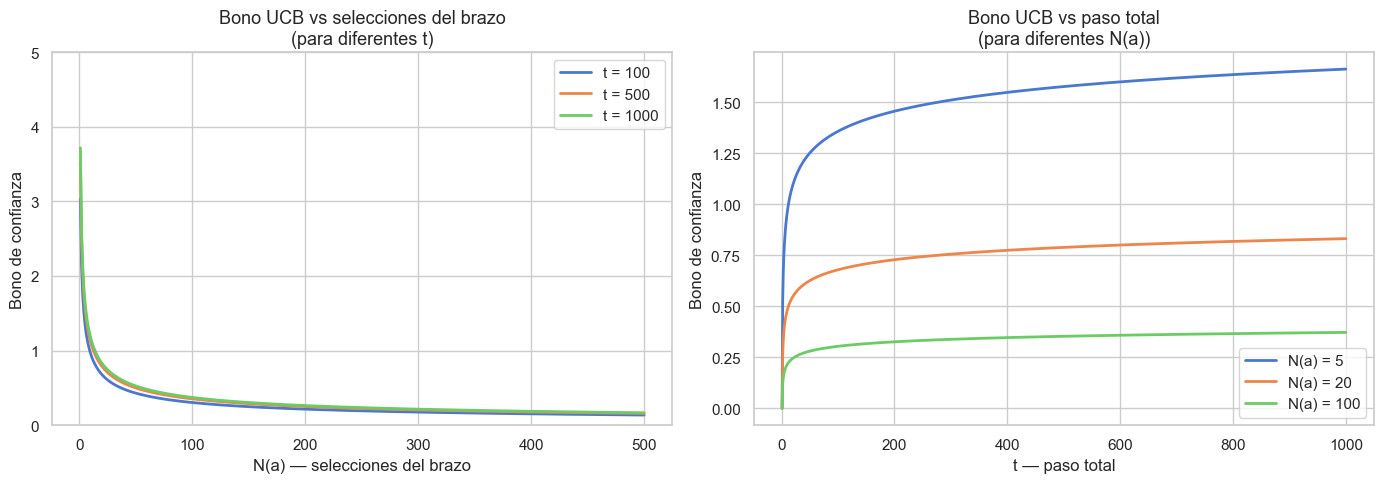

→ El bono decrece rápidamente con N(a): cuanto más se prueba un brazo, menos se explora.
→ El bono crece lentamente con t (logarítmicamente): garantiza exploración continua.


In [15]:
# Importar los nuevos algoritmos
from algorithms import UCB1, Softmax

# Demostración: cómo evoluciona el bono UCB con el tiempo
np.random.seed(42)
t_vals = np.arange(1, 1001)
c = np.sqrt(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: bono vs N(a) para t fijo
n_vals = np.arange(1, 501)
for t_fixed in [100, 500, 1000]:
    bonus = c * np.sqrt(np.log(t_fixed) / n_vals)
    axes[0].plot(n_vals, bonus, label=f't = {t_fixed}', linewidth=2)
axes[0].set_xlabel('N(a) — selecciones del brazo', fontsize=12)
axes[0].set_ylabel('Bono de confianza', fontsize=12)
axes[0].set_title('Bono UCB vs selecciones del brazo\n(para diferentes t)', fontsize=13)
axes[0].legend()
axes[0].set_ylim(0, 5)

# Panel derecho: bono vs t para N(a) fijo
for n_fixed in [5, 20, 100]:
    bonus = c * np.sqrt(np.log(t_vals) / n_fixed)
    axes[1].plot(t_vals, bonus, label=f'N(a) = {n_fixed}', linewidth=2)
axes[1].set_xlabel('t — paso total', fontsize=12)
axes[1].set_ylabel('Bono de confianza', fontsize=12)
axes[1].set_title('Bono UCB vs paso total\n(para diferentes N(a))', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()
print("→ El bono decrece rápidamente con N(a): cuanto más se prueba un brazo, menos se explora.")
print("→ El bono crece lentamente con t (logarítmicamente): garantiza exploración continua.")

### Verificación UCB1: convergencia al brazo óptimo

In [16]:
np.random.seed(42)

k_test = 10
bandit_ucb_test = Bandit(arms=ArmNormal.generate_arms(k_test))
algo_ucb = UCB1(k=k_test, c=np.sqrt(2))

# Ejecutar 2000 pasos
for _ in range(2000):
    arm = algo_ucb.select_arm()
    reward = bandit_ucb_test.pull_arm(arm)
    algo_ucb.update(arm, reward)

optimal = bandit_ucb_test.optimal_arm
most_selected = np.argmax(algo_ucb.counts)
print(f"Brazo óptimo: {optimal + 1} (E[X] = {bandit_ucb_test.get_expected_value(optimal):.2f})")
print(f"Brazo más seleccionado: {most_selected + 1} ({algo_ucb.counts[most_selected]} de 2000 veces)")
print(f"\nDistribución de selecciones:")
for i in range(k_test):
    marker = " ★" if i == optimal else ""
    bar = "█" * int(algo_ucb.counts[i] / 30)
    print(f"  Brazo {i+1:2d}: {algo_ucb.counts[i]:5d} | {bar}{marker}")

Brazo óptimo: 2 (E[X] = 9.56)
Brazo más seleccionado: 2 (1956 de 2000 veces)

Distribución de selecciones:
  Brazo  1:     1 | 
  Brazo  2:  1956 | █████████████████████████████████████████████████████████████████ ★
  Brazo  3:     3 | 
  Brazo  4:     2 | 
  Brazo  5:     1 | 
  Brazo  6:     1 | 
  Brazo  7:    28 | 
  Brazo  8:     3 | 
  Brazo  9:     4 | 
  Brazo 10:     1 | 


**Observación**: UCB1 concentra la gran mayoría de selecciones en el brazo óptimo, pero a diferencia de ε-greedy con ε=0, nunca deja de explorar completamente. Los demás brazos reciben un número reducido pero no nulo de selecciones, proporcional a su incertidumbre.

## 3.2 Softmax — Exploración de Boltzmann

### Idea clave: exploración proporcional a la calidad

En lugar de explorar uniformemente (ε-greedy) o por incertidumbre (UCB1), Softmax selecciona brazos con probabilidad proporcional a la exponencial de sus valores estimados:

$$P(A_t = a) = \frac{e^{Q_t(a) / \tau}}{\sum_{b=1}^{k} e^{Q_t(b) / \tau}}$$

**Parámetro τ (temperatura)**:
- $\tau \to \infty$: distribución uniforme → exploración pura
- $\tau \to 0^+$: distribución concentrada en el mejor → explotación pura (greedy)

**Ventaja clave sobre ε-greedy**: cuando ε-greedy explora, elige un brazo al azar con probabilidad uniforme, incluyendo brazos claramente malos. Softmax da más probabilidad a brazos que *parecen* prometedores y menos a brazos que parecen malos.

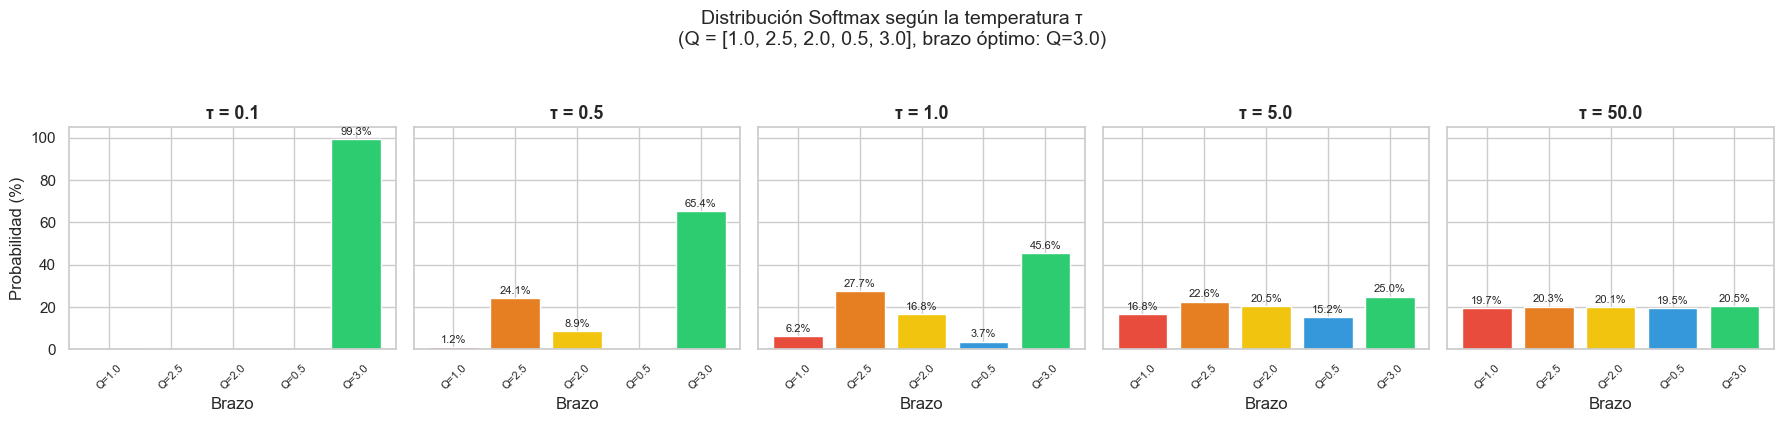

→ τ=0.1: prácticamente greedy (99%+ en el brazo con Q más alto)
→ τ=50:  casi uniforme (~20% cada brazo, ignora las estimaciones Q)


In [17]:
# Visualización: cómo cambia la distribución Softmax con la temperatura
np.random.seed(42)
Q_demo = np.array([1.0, 2.5, 2.0, 0.5, 3.0])  # Valores estimados de ejemplo
tau_values = [0.1, 0.5, 1.0, 5.0, 50.0]

fig, axes = plt.subplots(1, len(tau_values), figsize=(18, 4), sharey=True)
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#3498db', '#2ecc71']

for ax, tau in zip(axes, tau_values):
    scaled = Q_demo / tau
    scaled -= np.max(scaled)
    probs = np.exp(scaled) / np.sum(np.exp(scaled))
    
    bars = ax.bar(range(len(Q_demo)), probs * 100, color=colors, edgecolor='white')
    ax.set_title(f'τ = {tau}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Brazo')
    ax.set_xticks(range(len(Q_demo)))
    ax.set_xticklabels([f'Q={q}' for q in Q_demo], fontsize=8, rotation=45)
    ax.set_ylim(0, 105)
    if ax == axes[0]:
        ax.set_ylabel('Probabilidad (%)')
    
    # Mostrar probabilidades sobre las barras
    for bar, p in zip(bars, probs):
        if p > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{p:.1%}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Distribución Softmax según la temperatura τ\n(Q = [1.0, 2.5, 2.0, 0.5, 3.0], brazo óptimo: Q=3.0)', 
             fontsize=14, y=1.05)
plt.tight_layout()
plt.show()
print("→ τ=0.1: prácticamente greedy (99%+ en el brazo con Q más alto)")
print("→ τ=50:  casi uniforme (~20% cada brazo, ignora las estimaciones Q)")

### Verificación Softmax: convergencia al brazo óptimo

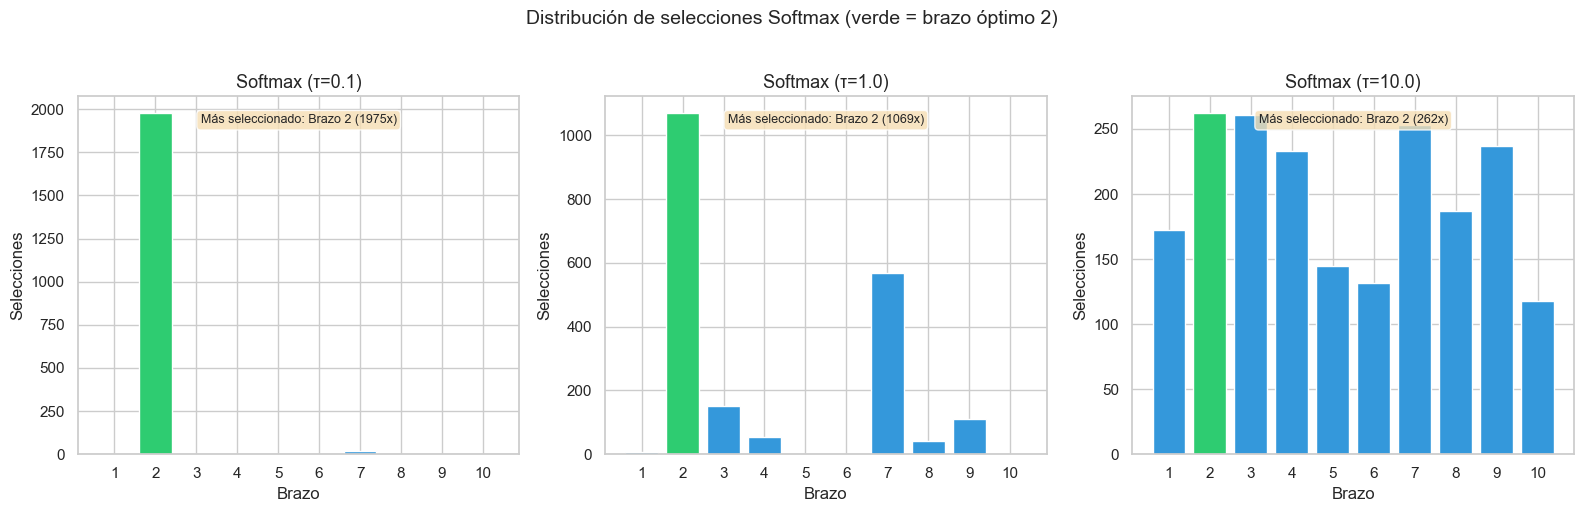

In [18]:
np.random.seed(42)

k_test = 10
bandit_sm_test = Bandit(arms=ArmNormal.generate_arms(k_test))
optimal_sm = bandit_sm_test.optimal_arm

# Comparar tres temperaturas
taus = [0.1, 1.0, 10.0]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, tau in zip(axes, taus):
    algo_sm = Softmax(k=k_test, tau=tau)
    for _ in range(2000):
        arm = algo_sm.select_arm()
        reward = bandit_sm_test.pull_arm(arm)
        algo_sm.update(arm, reward)
    
    colors = ['#2ecc71' if i == optimal_sm else '#3498db' for i in range(k_test)]
    ax.bar(range(k_test), algo_sm.counts, color=colors, edgecolor='white')
    ax.set_title(f'Softmax (τ={tau})', fontsize=13)
    ax.set_xlabel('Brazo')
    ax.set_ylabel('Selecciones')
    ax.set_xticks(range(k_test))
    ax.set_xticklabels([f'{i+1}' for i in range(k_test)])
    
    most = np.argmax(algo_sm.counts)
    ax.text(0.5, 0.95, f'Más seleccionado: Brazo {most+1} ({algo_sm.counts[most]}x)',
            transform=ax.transAxes, ha='center', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle(f'Distribución de selecciones Softmax (verde = brazo óptimo {optimal_sm+1})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Análisis del efecto de la temperatura**:
- **τ=0.1** (baja): Comportamiento casi greedy. Prácticamente todas las selecciones van al brazo óptimo.
- **τ=1.0** (media): Exploración proporcional. El brazo óptimo sigue siendo el más seleccionado, pero los demás reciben selecciones proporcionales a su valor estimado.
- **τ=10.0** (alta): Exploración excesiva. La distribución es casi uniforme, desperdiciando selecciones en brazos subóptimos.

## 3.3 Comparación rápida: ε-greedy vs UCB1 vs Softmax

Ejecutamos un experimento con los 3 algoritmos para comparar visualmente su rendimiento. Usamos los parámetros más representativos de cada uno.

In [19]:
# Experimento comparativo con los 3 algoritmos
np.random.seed(42)

k = 10
steps = 1000
runs = 500

bandit_cmp = Bandit(arms=ArmNormal.generate_arms(k))
print(bandit_cmp)
print(f"Brazo óptimo: {bandit_cmp.optimal_arm + 1} con E[X] = {bandit_cmp.get_expected_value(bandit_cmp.optimal_arm):.2f}")

# Algoritmos representativos de cada familia
algorithms_cmp = [
    EpsilonGreedy(k=k, epsilon=0.1),   # ε-greedy con exploración moderada
    UCB1(k=k, c=np.sqrt(2)),           # UCB1 con valor teórico
    Softmax(k=k, tau=0.5),             # Softmax con temperatura intermedia-baja
]

print(f"\nEjecutando {runs} ejecuciones de {steps} pasos cada una...")
rewards_cmp, opt_sel_cmp, regret_cmp, arm_stats_cmp = run_experiment(bandit_cmp, algorithms_cmp, steps, runs)
print("¡Experimento completado!")

Bandit with 10 arms: ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0)
Brazo óptimo: 2 con E[X] = 9.56

Ejecutando 500 ejecuciones de 1000 pasos cada una...
¡Experimento completado!


### Recompensa Promedio

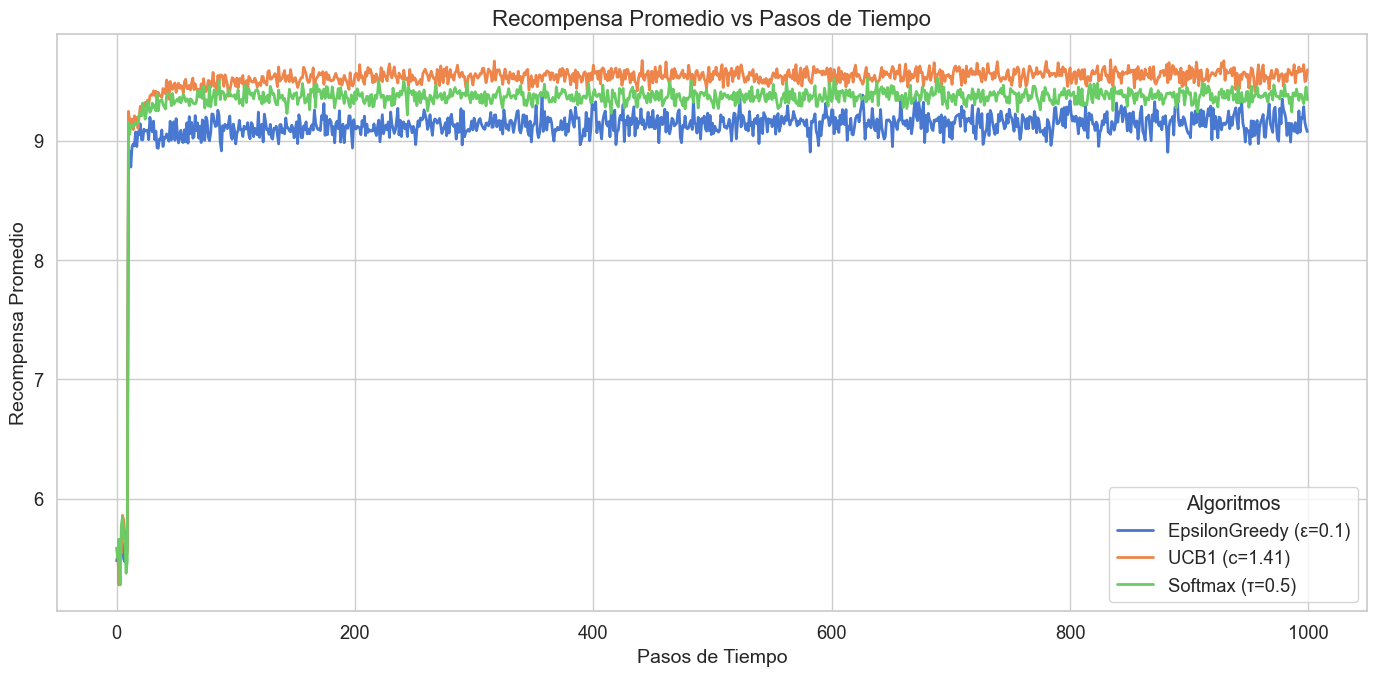

In [20]:
plot_average_rewards(steps, rewards_cmp, algorithms_cmp)

### Selección del Brazo Óptimo

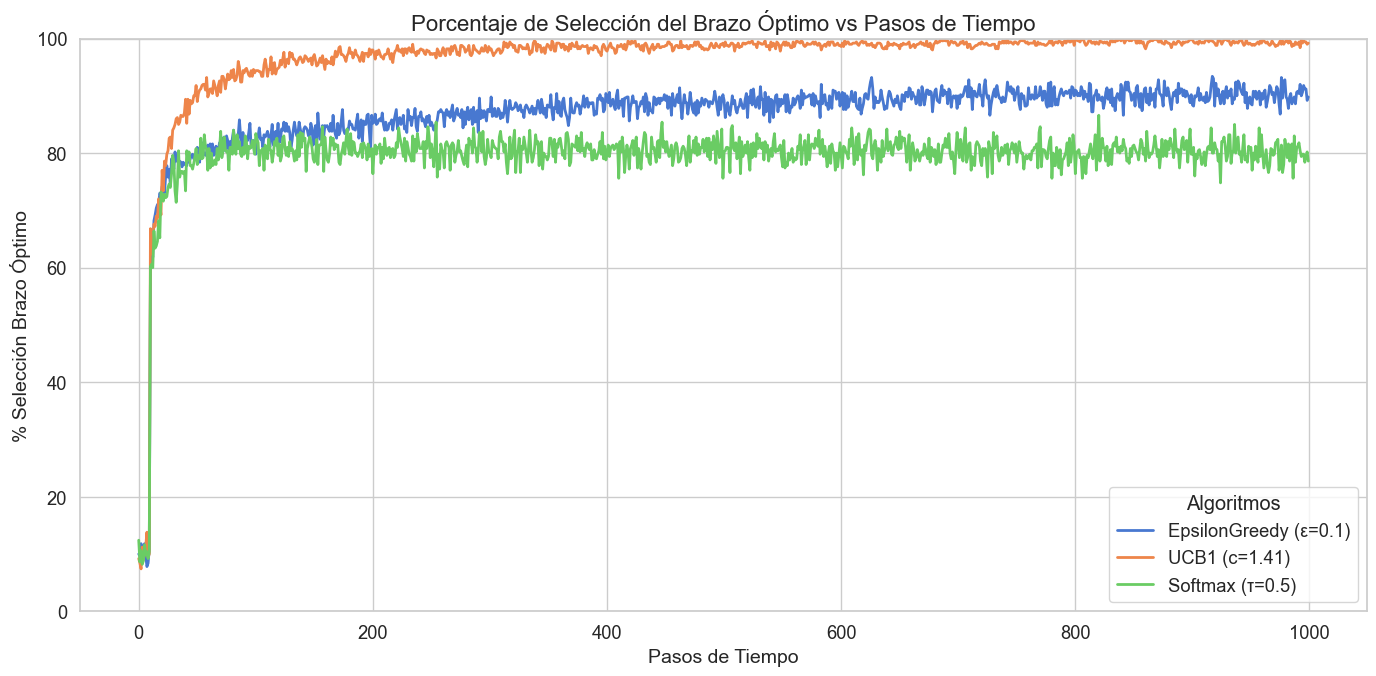

In [21]:
plot_optimal_selections(steps, opt_sel_cmp, algorithms_cmp)

### Regret Acumulado

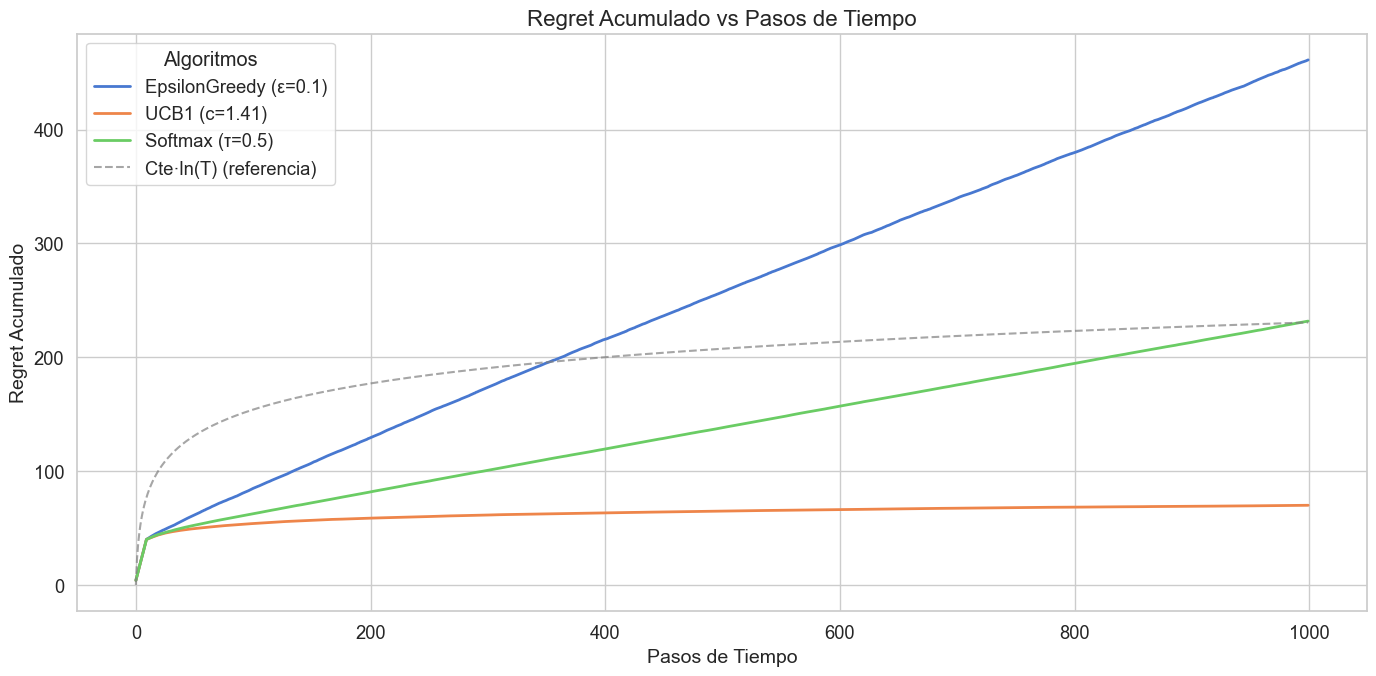

In [22]:
plot_regret(steps, regret_cmp, algorithms_cmp, show_log_bound=True)

### Estadísticas por Brazo

f:\UM\MASTER\EML\P1\Bandido-k-brazos\eml_k_bandit-main\plotting\plotting.py:202: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
f:\UM\MASTER\ML\ml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


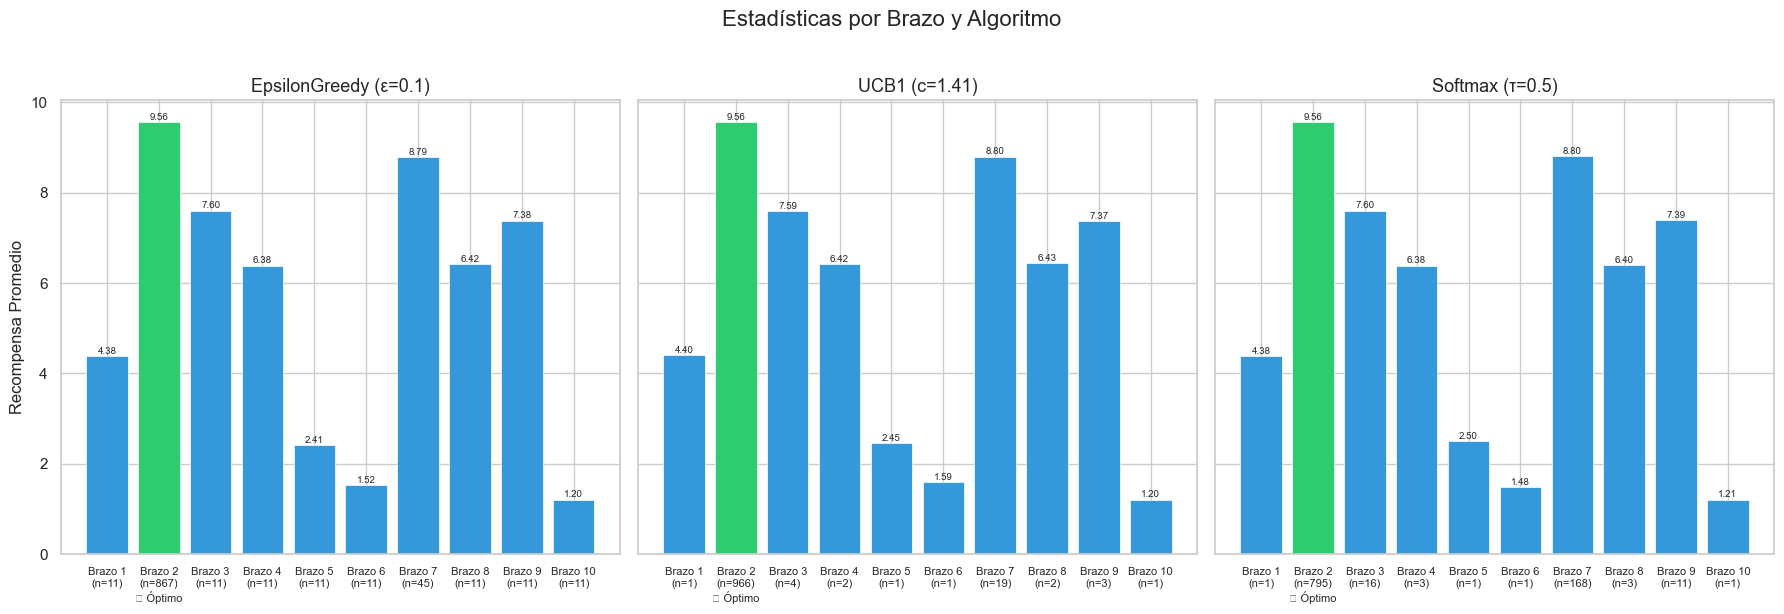

In [23]:
plot_arm_statistics(arm_stats_cmp, algorithms_cmp)

### Análisis de la comparación ε-greedy vs UCB1 vs Softmax

**Recompensa promedio**:
- UCB1 alcanza la recompensa más alta más rápidamente y la mantiene. Esto se debe a que su exploración es dirigida (brazos inciertos) y no desperdicia tiempo en brazos claramente subóptimos.
- Softmax (τ=0.5) se sitúa entre UCB1 y ε-greedy porque su exploración es proporcional a la calidad estimada.
- ε-greedy (ε=0.1) converge a un nivel inferior: el 10% de exploración uniforme penaliza permanentemente la recompensa.

**Selección del brazo óptimo**:
- UCB1 tiende al 100% de selección óptima porque su exploración decrece naturalmente (el bono se reduce con más selecciones).
- ε-greedy se estabiliza en ~91% (limitado por el 10% de exploración forzada).

**Regret acumulado** — La gráfica más reveladora:
- **ε-greedy**: regret **lineal** → ε fijo genera un coste constante por paso de exploración no productiva.
- **UCB1**: regret **logarítmico** → se acerca a la cota teórica de Lai-Robbins. La exploración decrece y el coste marginal tiende a cero.
- **Softmax**: regret intermedio. Con τ fijo, la exploración no desaparece completamente pero es más inteligente que la uniforme.

**Conclusión**: UCB1 es el ganador teórico claro en este escenario con distribución Normal, gracias a su regret logarítmico. Sin embargo, su rendimiento depende de la elección de c y de la escala de las recompensas. Softmax ofrece un buen compromiso cuando se quiere exploración proporcional a la calidad estimada.

---


